In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from atmo3 import grid_utils as gutl
from atmo3 import box
from atmo3 import atm_utils as au
from atmo3 import constants as const
import matplotlib.pyplot as plt

In [2]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, csd

# ==============================================================================
# 1. Load the Data and Set Parameters
# ==============================================================================
# Load the dataset you generated on Perlmutter
#data = np.load("/pscratch/sd/v/valer/atmo3/notebooks/lidar_noise/lidar_tod_ensemble_900_runs.npz") #the first test
data = np.load("/pscratch/sd/v/valer/atmo3/notebooks/lidar_noise/lidar_tod_ensemble_99_runs_wind_5.0.npz")
s_i = data['true_signal']   # Shape: (Total_Sims, Nz, Time_Steps)
#x_i = data['noisy_signal']  # Shape: (Total_Sims, Nz, Time_Steps)
n_i = data['pure_noise']    # Shape: (Total_Sims, Nz, Time_Steps)
altitudes = data['altitude_axis']
total_sims = s_i.shape[0]



In [4]:
#Let's reduce the noise by 90 % of x_i to see if we can get a better estimate of the true signal

x_i = 4*s_i + n_i

s_i = 4*s_i

In [5]:
# Signal Parameters (Must match your generation script)
fs_lidar = 1.0 / 10.0
n_window = 360 

Nz = len(altitudes)

# Define your integration cutoff altitude (e.g., 4000 meters)
target_z_int = 4000.0
# Find the exact array index closest to your target altitude
z_int_idx = np.argmin(np.abs(altitudes - target_z_int))

print(f"Integrating Lidar up to Index {z_int_idx} (Exact Altitude: {altitudes[z_int_idx]:.1f} m)")
print(f"Total Sky integration up to Index {len(altitudes)} (Exact Altitude: {altitudes[-1]:.1f} m)")

# ==============================================================================
# 2. Time-Domain Summation (Collapsing the Layers)
# ==============================================================================
# Sum along axis=1 (the altitude layers)
# 1. The Truncated Sums (Up to z_int)
s_z_int = np.sum(s_i[:, :z_int_idx, :], axis=1)  # Shape: (Total_Sims, Time_Steps)
x_z_int = np.sum(x_i[:, :z_int_idx, :], axis=1)
n_z_int = np.sum(n_i[:, :z_int_idx, :], axis=1)

# 2. The Total Sky Sums (Up to z_max)
s_z_max = np.sum(s_i, axis=1)
x_z_max = np.sum(x_i, axis=1)

# ==============================================================================
# 3. Frequency-Domain Analysis (Vectorized across all simulations)
# ==============================================================================
# Define how many hours (simulations) you want to integrate over. 
# You can change this to 10, 100, or total_sims to watch the noise floor drop!
obs_hours = 1 
print(f"Averaging {obs_hours} hours of observation time (out of {total_sims} available).")

# We use axis=-1 to tell SciPy to calculate the FFT along the Time_Steps axis
# SciPy calculates all simulations, but np.mean ONLY averages the first 'obs_hours'

# Auto-Spectra
freqs, psd_s_z_max = welch(s_z_max, fs=fs_lidar, nperseg=n_window, axis=-1)
psd_s_z_max_mean = np.mean(psd_s_z_max[:obs_hours, :], axis=0)

freqs, psd_x_z_int = welch(x_z_int, fs=fs_lidar, nperseg=n_window, axis=-1)
psd_x_z_int_mean = np.mean(psd_x_z_int[:obs_hours, :], axis=0)

freqs, psd_x_z_max = welch(x_z_max, fs=fs_lidar, nperseg=n_window, axis=-1)
psd_x_z_max_mean = np.mean(psd_x_z_max[:obs_hours, :], axis=0)

# Calculate the pure noise floor of our safe integration
freqs, psd_n_z_int = welch(n_z_int, fs=fs_lidar, nperseg=n_window, axis=-1)
psd_n_z_int_mean = np.mean(psd_n_z_int[:obs_hours, :], axis=0)

# Calculate the error psd of X_z_int - S_z_max 
freqs, psd_error = welch(x_z_int - s_z_max, fs=fs_lidar, nperseg=n_window, axis=-1)
psd_error_mean = np.mean(psd_error[:obs_hours, :], axis=0)

# Cross-Spectra
# 1. Lidar cut off at z_int vs. True Sky cut off at z_int (Perfect overlap)
_, csd_sx_int = csd(s_z_int, x_z_int, fs=fs_lidar, nperseg=n_window, axis=-1)
_, csd_xs_int = csd(x_z_int, s_z_int, fs=fs_lidar, nperseg=n_window, axis=-1)
cpsd_int_mean = np.mean(np.real(0.5 * (csd_sx_int + csd_xs_int))[:obs_hours, :], axis=0)

# 2. THE REALITY CHECK: Lidar cut off at z_int vs. TOTAL True Sky
_, csd_sx_real = csd(s_z_max, x_z_int, fs=fs_lidar, nperseg=n_window, axis=-1)
_, csd_xs_real = csd(x_z_int, s_z_max, fs=fs_lidar, nperseg=n_window, axis=-1)
cpsd_real_mean = np.mean(np.real(0.5 * (csd_sx_real + csd_xs_real))[:obs_hours, :], axis=0)


Integrating Lidar up to Index 53 (Exact Altitude: 3990.0 m)
Total Sky integration up to Index 325 (Exact Altitude: 12120.0 m)
Averaging 1 hours of observation time (out of 99 available).


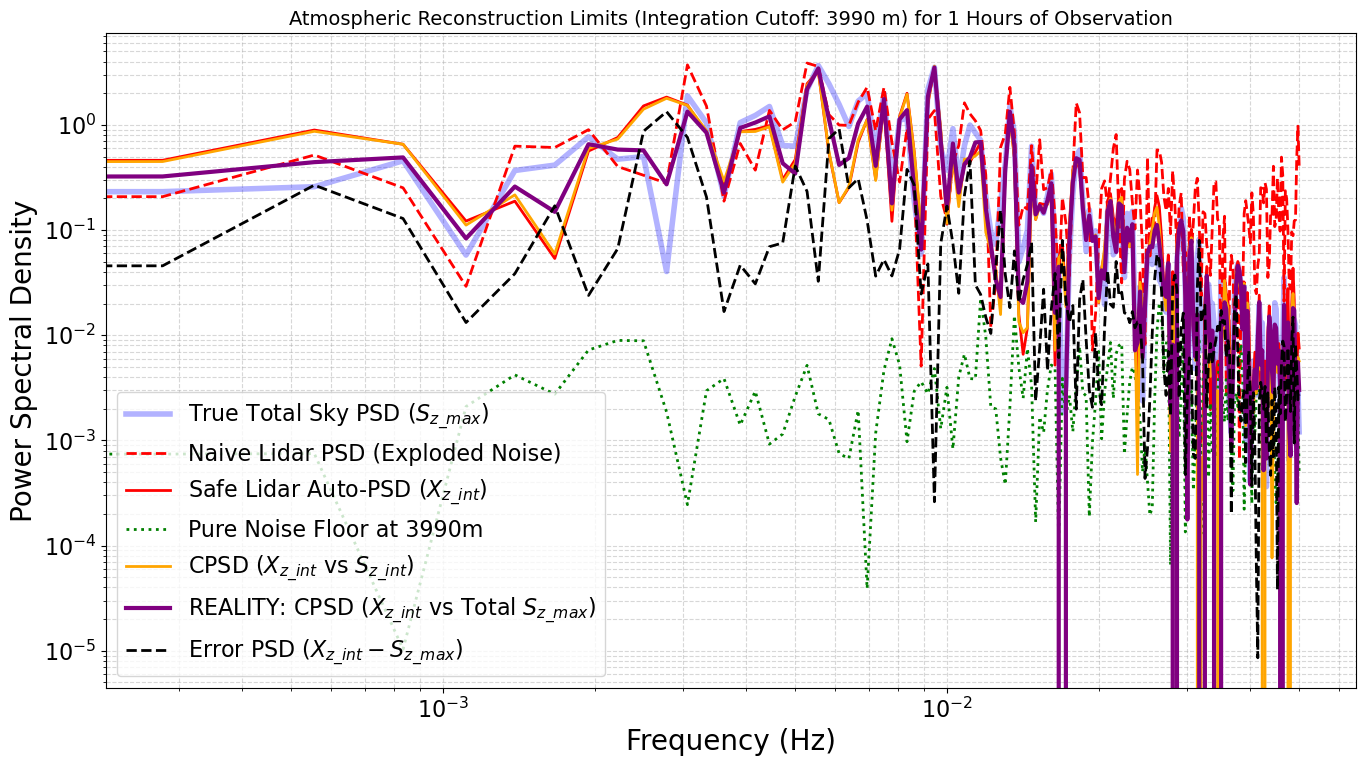

In [6]:
# ==============================================================================
# 4. Plotting the Results
# ==============================================================================
plt.figure(figsize=(14, 8))

# 1. The Target (What we want to measure)
plt.loglog(freqs, psd_s_z_max_mean, label=r'True Total Sky PSD ($S_{z\_max}$)', color='blue', linewidth=4, alpha=0.3)

# 2. The Naive Trap (Measuring everything)
plt.loglog(freqs, psd_x_z_max_mean, label='Naive Lidar PSD (Exploded Noise)', color='red', linestyle='--', linewidth=2)

# 3. The Safe Lidar Auto-Spectrum (NEW LINE: What happens without cross-correlation)
plt.loglog(freqs, psd_x_z_int_mean, label=rf'Safe Lidar Auto-PSD ($X_{{z\_int}}$)', color='red', linewidth=2)

# 3. The Pure Noise Barrier (If we didn't use Cross-Spectra)
plt.loglog(freqs, psd_n_z_int_mean, label=rf'Pure Noise Floor at {altitudes[z_int_idx]:.0f}m', color='green', linestyle=':', linewidth=2)

# 4. The Safe Lidar Cross-Spectrum (Measuring up to z_int)
plt.loglog(freqs, cpsd_int_mean, label=rf'CPSD ($X_{{z\_int}}$ vs $S_{{z\_int}}$)', color='orange', linewidth=2)

# 5. The Reality Check (Safe Lidar vs Total Sky)
plt.loglog(freqs, cpsd_real_mean, label=rf'REALITY: CPSD ($X_{{z\_int}}$ vs Total $S_{{z\_max}}$)', color='purple', linewidth=3)

plt.loglog(freqs, psd_error_mean, label=rf'Error PSD ($X_{{z\_int}} - S_{{z\_max}}$)', color='black', linestyle='--', linewidth=2)

plt.title(f'Atmospheric Reconstruction Limits (Integration Cutoff: {altitudes[z_int_idx]:.0f} m) for {obs_hours} Hours of Observation', fontsize=14)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

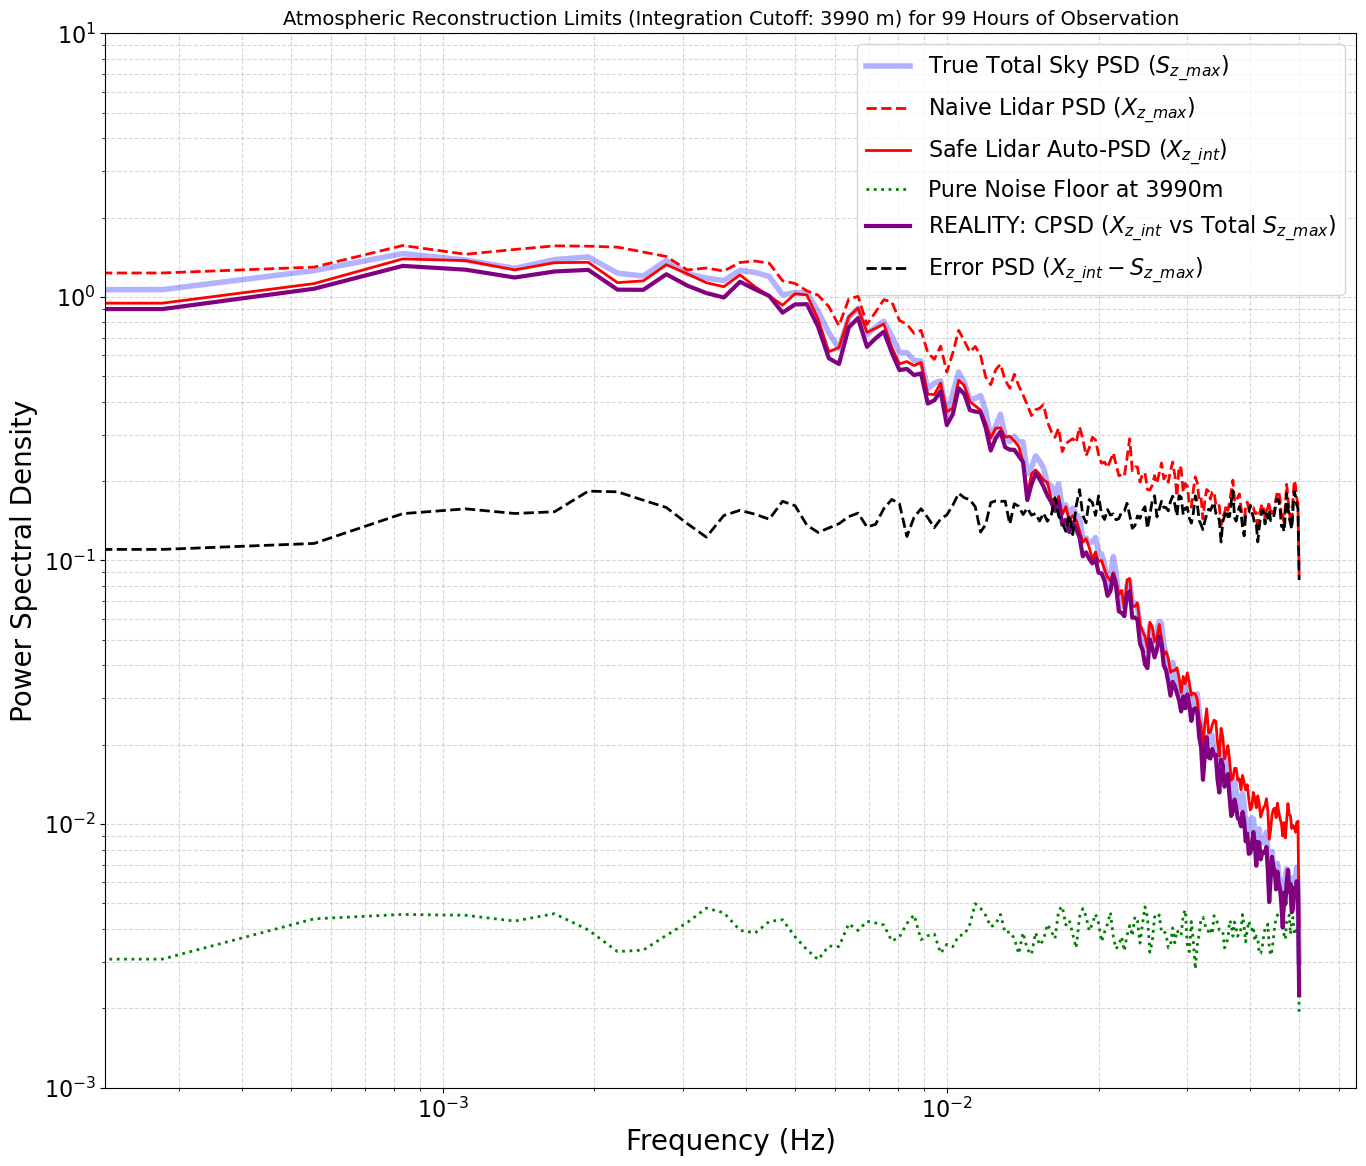

In [42]:
# ==============================================================================
# 4. Plotting the Results
# ==============================================================================
plt.figure(figsize=(14, 12))

# 1. The Target (What we want to measure)
plt.loglog(freqs, psd_s_z_max_mean, label=r'True Total Sky PSD ($S_{z\_max}$)', color='blue', linewidth=4, alpha=0.3)

# 2. The Naive Trap (Measuring everything)
plt.loglog(freqs, psd_x_z_max_mean, label=r'Naive Lidar PSD ($X_{z\_max}$)', color='red', linestyle='--', linewidth=2)

# 3. The Safe Lidar Auto-Spectrum (NEW LINE: What happens without cross-correlation)
plt.loglog(freqs, psd_x_z_int_mean, label=rf'Safe Lidar Auto-PSD ($X_{{z\_int}}$)', color='red', linewidth=2)

# 3. The Pure Noise Barrier (If we didn't use Cross-Spectra)
plt.loglog(freqs, psd_n_z_int_mean, label=rf'Pure Noise Floor at {altitudes[z_int_idx]:.0f}m', color='green', linestyle=':', linewidth=2)

# 4. The Safe Lidar Cross-Spectrum (Measuring up to z_int)
#plt.loglog(freqs, cpsd_int_mean, label=rf'CPSD ($X_{{z\_int}}$ vs $S_{{z\_int}}$)', color='orange', linewidth=2)

# 5. The Reality Check (Safe Lidar vs Total Sky)
plt.loglog(freqs, cpsd_real_mean, label=rf'REALITY: CPSD ($X_{{z\_int}}$ vs Total $S_{{z\_max}}$)', color='purple', linewidth=3)

plt.loglog(freqs, psd_error_mean, label=rf'Error PSD ($X_{{z\_int}} - S_{{z\_max}}$)', color='black', linestyle='--', linewidth=2)

plt.title(f'Atmospheric Reconstruction Limits (Integration Cutoff: {altitudes[z_int_idx]:.0f} m) for {obs_hours} Hours of Observation', fontsize=14)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.ylim(1e-3,1e1)
plt.tight_layout()
plt.show()

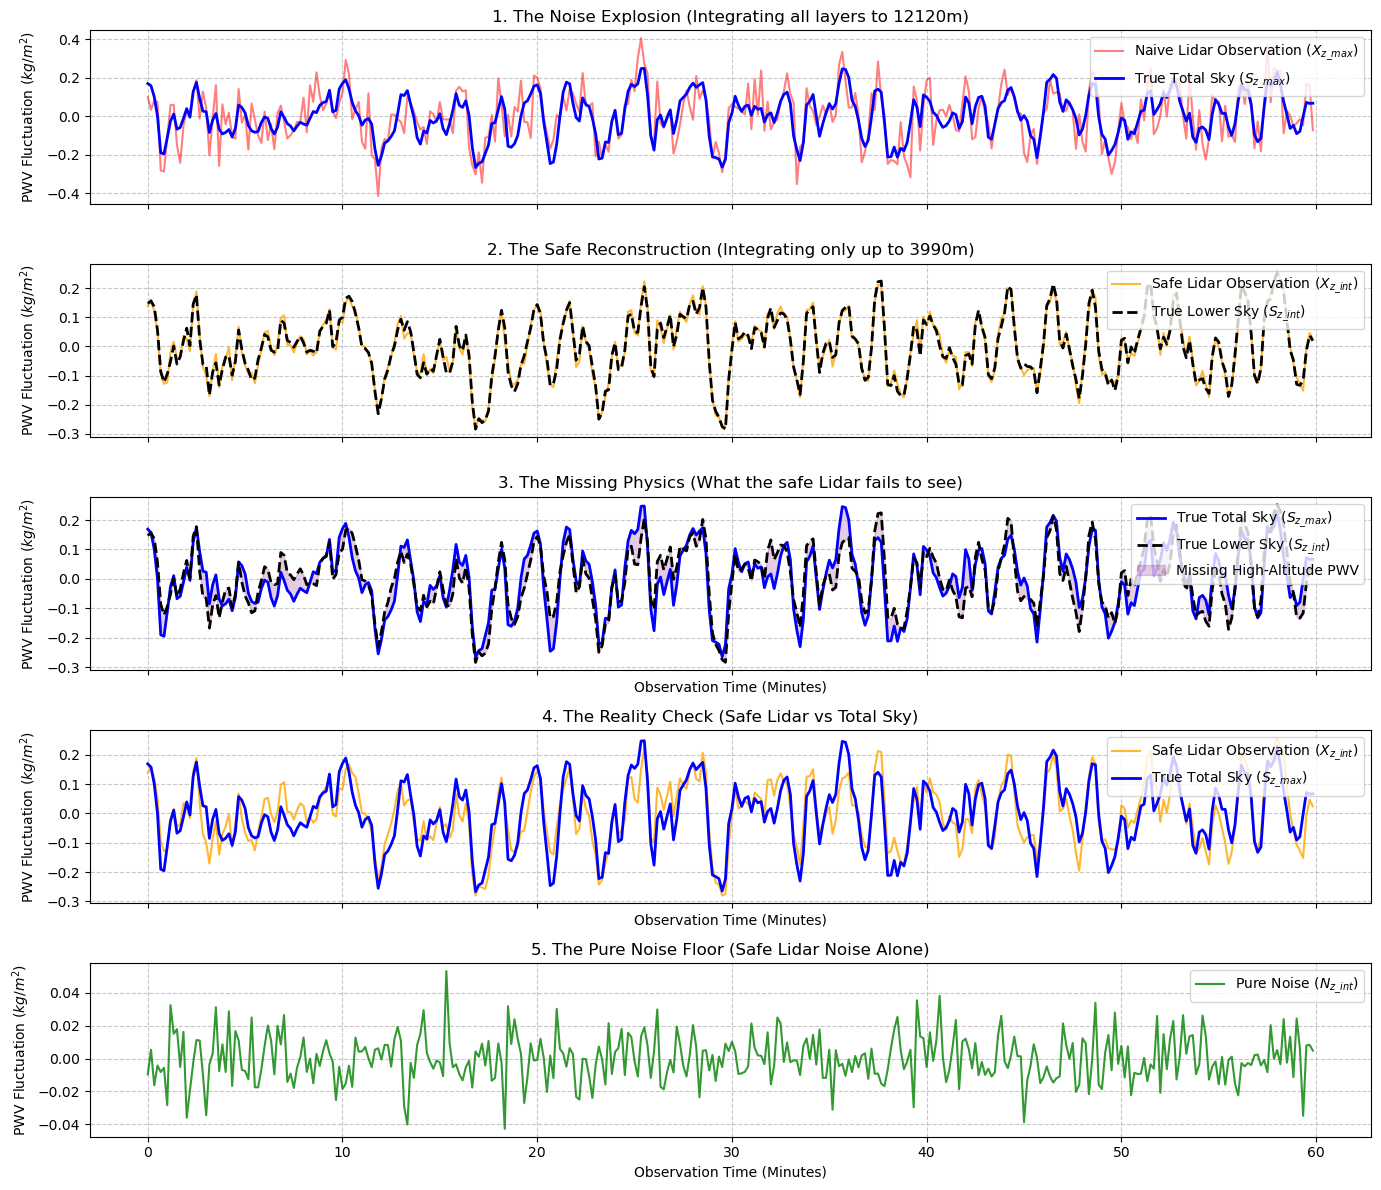

In [6]:
# ==============================================================================
# 5. Time-Domain Reality Check (Visualizing a single 1-hour scan)
# ==============================================================================
# Pick one specific simulation to look at (0 to total_sims-1)
sim_idx = 0 

# Create a time axis in minutes (Lidar fires every 10s)
time_axis_min = np.arange(s_z_max.shape[1]) * 10.0 / 60.0

fig, axs = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# ------------------------------------------------------------------------------
# Panel 1: The Naive Trap (Total Lidar vs Total Sky)
# ------------------------------------------------------------------------------
axs[0].plot(time_axis_min, x_z_max[sim_idx, :], color='red', alpha=0.5, label=r'Naive Lidar Observation ($X_{z\_max}$)')
axs[0].plot(time_axis_min, s_z_max[sim_idx, :], color='blue', linewidth=2, label=r'True Total Sky ($S_{z\_max}$)')
axs[0].set_title(f'1. The Noise Explosion (Integrating all layers to {altitudes[-1]:.0f}m)')
axs[0].set_ylabel(r'PWV Fluctuation ($kg/m^2$)')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.7)

# ------------------------------------------------------------------------------
# Panel 2: The Safe Lidar (Safe Lidar vs Safe Sky)
# ------------------------------------------------------------------------------
axs[1].plot(time_axis_min, x_z_int[sim_idx, :], color='orange', alpha=0.8, label=r'Safe Lidar Observation ($X_{z\_int}$)')
axs[1].plot(time_axis_min, s_z_int[sim_idx, :], color='black', linewidth=2, linestyle='--', label=r'True Lower Sky ($S_{z\_int}$)')
axs[1].set_title(f'2. The Safe Reconstruction (Integrating only up to {altitudes[z_int_idx]:.0f}m)')
axs[1].set_ylabel(r'PWV Fluctuation ($kg/m^2$)')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.7)

# ------------------------------------------------------------------------------
# Panel 3: The Missing Physics (Total Sky vs Safe Sky)
# ------------------------------------------------------------------------------
axs[2].plot(time_axis_min, s_z_max[sim_idx, :], color='blue', linewidth=2, label=r'True Total Sky ($S_{z\_max}$)')
axs[2].plot(time_axis_min, s_z_int[sim_idx, :], color='black', linewidth=2, linestyle='--', label=r'True Lower Sky ($S_{z\_int}$)')

# Shade the difference (The missing high-altitude water vapor)
axs[2].fill_between(time_axis_min, s_z_max[sim_idx, :], s_z_int[sim_idx, :], color='purple', alpha=0.2, label='Missing High-Altitude PWV')

axs[2].set_title('3. The Missing Physics (What the safe Lidar fails to see)')
axs[2].set_xlabel('Observation Time (Minutes)')
axs[2].set_ylabel(r'PWV Fluctuation ($kg/m^2$)')
axs[2].legend(loc='upper right')
axs[2].grid(True, linestyle='--', alpha=0.7)

# ------------------------------------------------------------------------------
# Panel 4: Safe Lidar vs Total sky
# ------------------------------------------------------------------------------

axs[3].plot(time_axis_min, x_z_int[sim_idx, :], color='orange', alpha=0.8, label=r'Safe Lidar Observation ($X_{z\_int}$)')
axs[3].plot(time_axis_min, s_z_max[sim_idx, :], color='blue', linewidth=2, label=r'True Total Sky ($S_{z\_max}$)')
axs[3].set_title(f'4. The Reality Check (Safe Lidar vs Total Sky)')
axs[3].set_xlabel('Observation Time (Minutes)')
axs[3].set_ylabel(r'PWV Fluctuation ($kg/m^2$)')
axs[3].legend(loc='upper right')
axs[3].grid(True, linestyle='--', alpha=0.7)

#Let's just plot the noise alone for the last panel
axs[4].plot(time_axis_min, n_z_int[sim_idx, :], color='green', alpha=0.8, label=r'Pure Noise ($N_{z\_int}$)')
axs[4].set_title(f'5. The Pure Noise Floor (Safe Lidar Noise Alone)')
axs[4].set_xlabel('Observation Time (Minutes)')
axs[4].set_ylabel(r'PWV Fluctuation ($kg/m^2$)')
axs[4].legend(loc='upper right')
axs[4].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

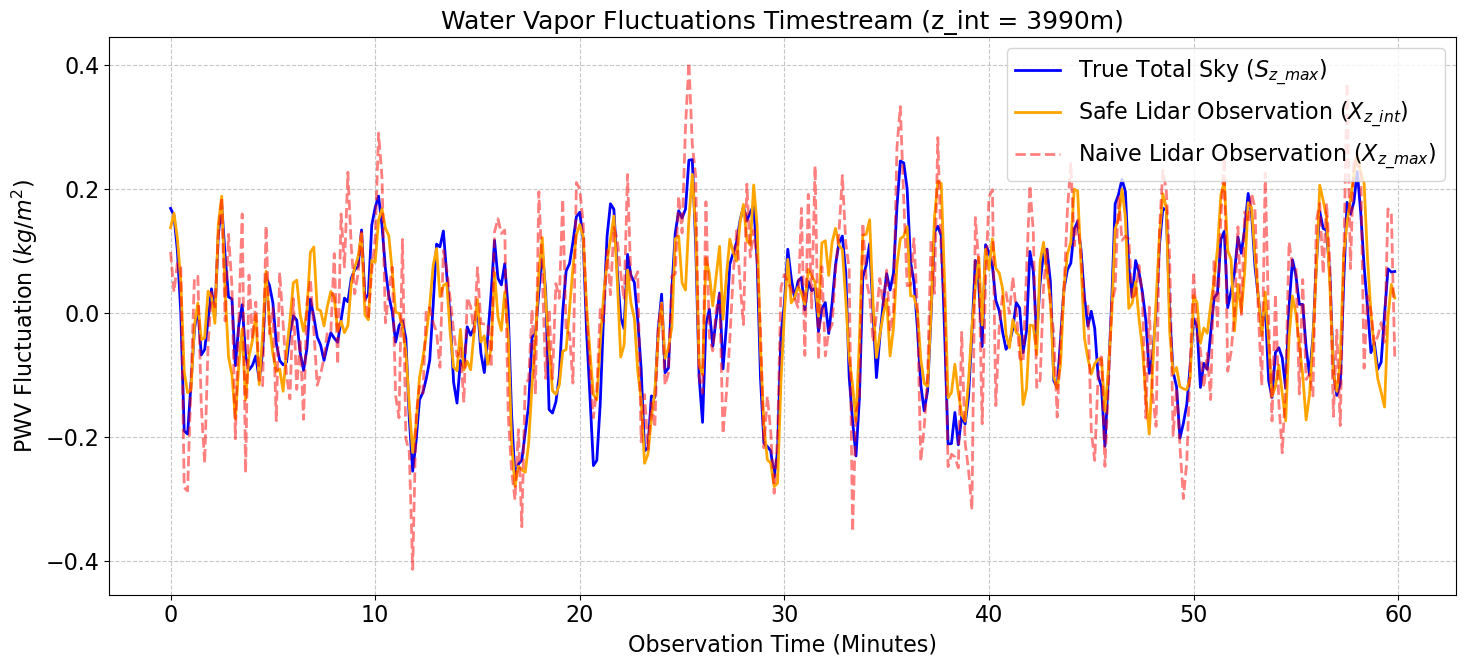

In [17]:
import matplotlib.pyplot as plt

# Single time-domain comparison plot
plt.figure(figsize=(15, 7))
plt.plot(time_axis_min, s_z_max[sim_idx, :], color='blue', linewidth=2, label=r'True Total Sky ($S_{z\_max}$)')
plt.plot(time_axis_min, x_z_int[sim_idx, :], color='orange', linewidth=2, label=r'Safe Lidar Observation ($X_{z\_int}$)')
plt.plot(time_axis_min, x_z_max[sim_idx, :], color='red', linewidth=2, linestyle='--', label=r'Naive Lidar Observation ($X_{z\_max}$)', alpha=0.5)

plt.title(f'Water Vapor Fluctuations Timestream (z_int = {altitudes[z_int_idx]:.0f}m)', fontsize=18)
plt.xlabel('Observation Time (Minutes)', fontsize=16)
plt.ylabel(r'PWV Fluctuation ($kg/m^2$)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

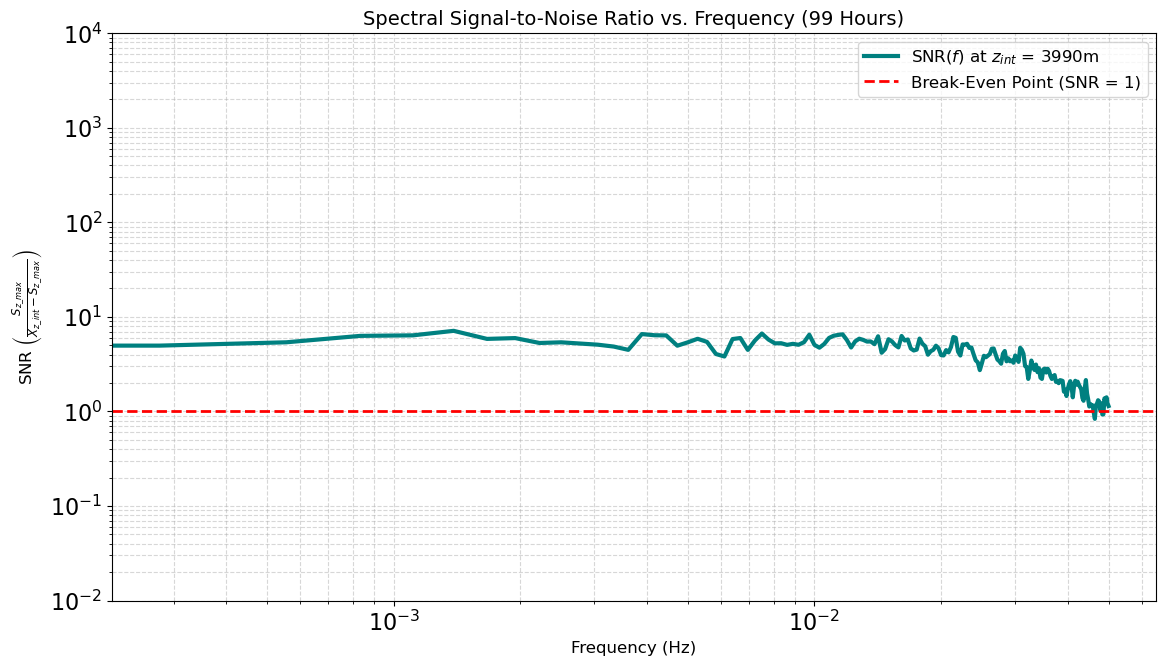

In [19]:
# 2. Calculate SNR(f)
# SNR = True Total Sky PSD / Error PSD
snr_f = psd_s_z_max_mean / psd_error_mean

# ==============================================================================
# Plotting SNR(f)
# ==============================================================================
plt.figure(figsize=(12, 7))

# Plot the SNR curve
plt.loglog(freqs, snr_f, color='teal', linewidth=3, label=rf'SNR($f$) at $z_{{int}}$ = {altitudes[z_int_idx]:.0f}m')

# The Critical Boundary: SNR = 1
# Above this line: Lidar helps. Below this line: Lidar hurts.
plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Break-Even Point (SNR = 1)')

# Formatting the plot
plt.title(f'Spectral Signal-to-Noise Ratio vs. Frequency ({obs_hours} Hours)', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel(r'SNR $\left( \frac{S_{z\_max}}{X_{z\_int} - S_{z\_max}} \right)$', fontsize=12)

# Set Y-axis limits to frame the crossing point cleanly
plt.ylim(1e-2, 1e4)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

Calculating full SNR(f) matrix for 99 hours...


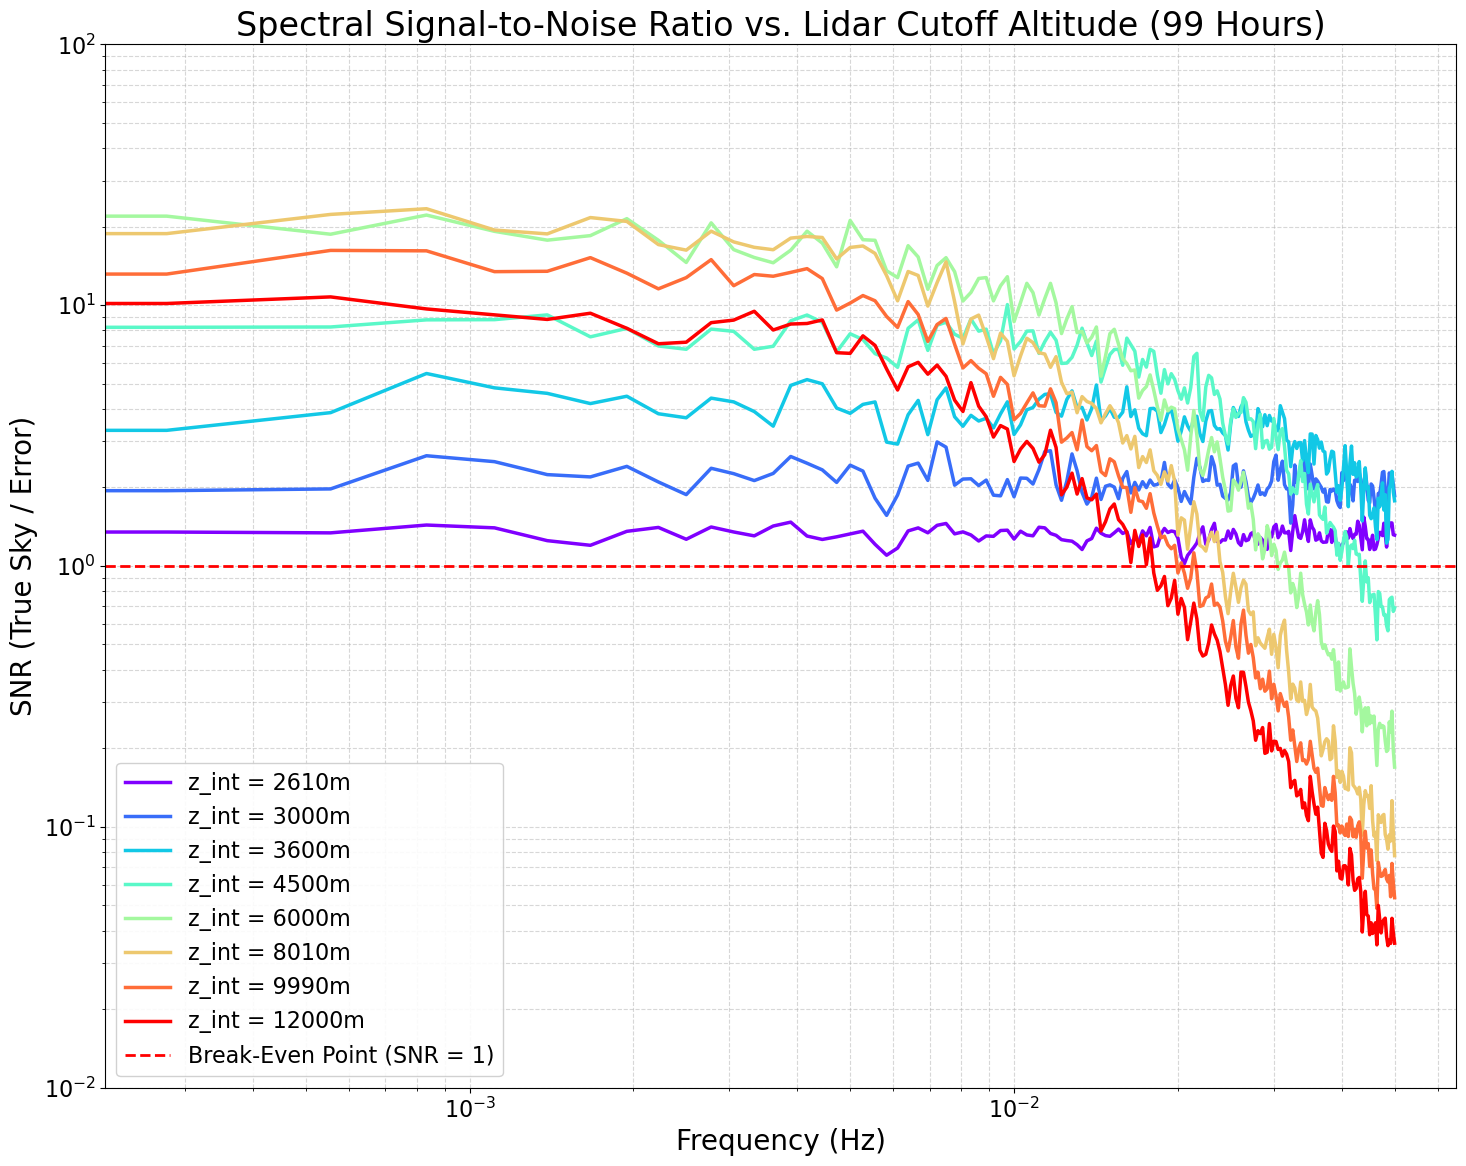

/tmp/ipykernel_2354106/191973508.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


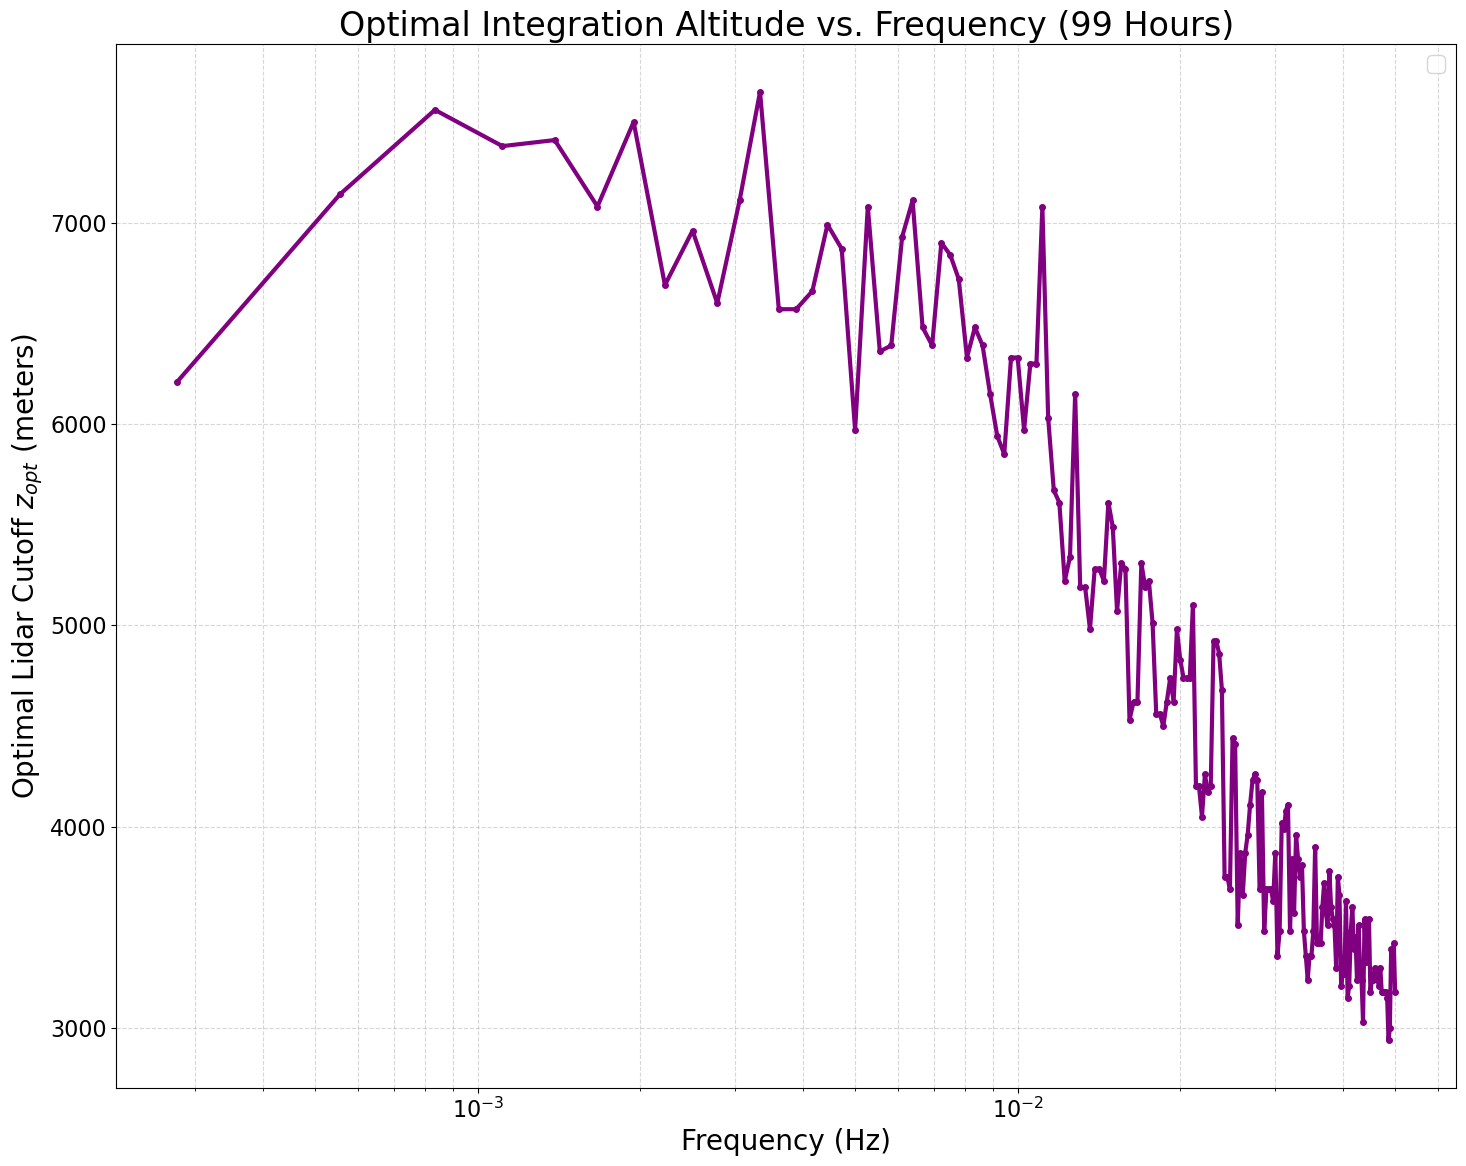

In [26]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# 9. Calculate Spectral SNR for ALL Integration Altitudes
# ==============================================================================
print(f"Calculating full SNR(f) matrix for {obs_hours} hours...")

# Pre-allocate array for speed: Shape (Nz, N_freqs)
master_snr_f = np.zeros((Nz, len(freqs)))

# Loop over every single altitude layer
for z_idx in range(1, Nz):
    # 1. Truncate Lidar observation up to the current z_idx
    x_z_current = np.sum(x_i[:obs_hours, :z_idx, :], axis=1)
    
    # 2. Calculate the Error PSD
    _, psd_error = welch(x_z_current - s_z_max[:obs_hours, :], fs=fs_lidar, nperseg=n_window, axis=-1)
    psd_error_mean = np.mean(psd_error, axis=0)
    
    # 3. Calculate and store SNR(f)
    master_snr_f[z_idx, :] = psd_s_z_max_mean / (psd_error_mean + 1e-12)

# ==============================================================================
# PLOT 1: The SNR(f) Curves for Selected Altitudes
# ==============================================================================
plt.figure(figsize=(15, 12))

target_altitudes_to_plot = [2600.0, 3000.0, 3600.0, 4500.0, 6000.0, 8000.0, 10000.0, 12000.0]
colors = cm.rainbow(np.linspace(0, 1, len(target_altitudes_to_plot)))

for i, target_alt in enumerate(target_altitudes_to_plot):
    plot_idx = np.argmin(np.abs(altitudes - target_alt))
    actual_alt = altitudes[plot_idx]
    
    plt.loglog(
        freqs, 
        master_snr_f[plot_idx, :], 
        color=colors[i], 
        linewidth=2.5, 
        label=rf'z_int = {actual_alt:.0f}m'
    )

plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Break-Even Point (SNR = 1)')
plt.title(f'Spectral Signal-to-Noise Ratio vs. Lidar Cutoff Altitude ({obs_hours} Hours)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('SNR (True Sky / Error)')
plt.ylim(1e-2, 1e2)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()

# ==============================================================================
# 10. Extract and Plot z_opt = g(f)
# ==============================================================================
# We skip row 0 (z_idx = 0) because we started our calculation loop at index 1.
# np.argmax scans along axis=0 (the altitude rows) for every frequency column.
optimal_z_indices = np.argmax(master_snr_f[1:, :], axis=0) + 1 

# Map the winning indices back to their physical physical altitudes
z_opt_f = altitudes[optimal_z_indices]

# Ignore the DC component (f=0) which often behaves strangely due to mean-subtraction
valid_f = freqs[1:]
valid_z = z_opt_f[1:]

# PLOT 2: The Optimal Integration Boundary
plt.figure(figsize=(15, 12))

# We use semilogx because frequency spans magnitudes, but altitude is linear
plt.semilogx(valid_f, valid_z, color='purple', linewidth=3, marker='o', markersize=4)

plt.title(f'Optimal Integration Altitude vs. Frequency ({obs_hours} Hours)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Optimal Lidar Cutoff $z_{opt}$ (meters)')

# Add a subtle background shading to show the "Safe" vs "Danger" zones
#plt.fill_between(valid_f, 2400.0, valid_z, color='purple', alpha=0.1, label='Safe Integration Zone')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Building Full-Spectrum Hybrid Estimator and returning to Time Domain...


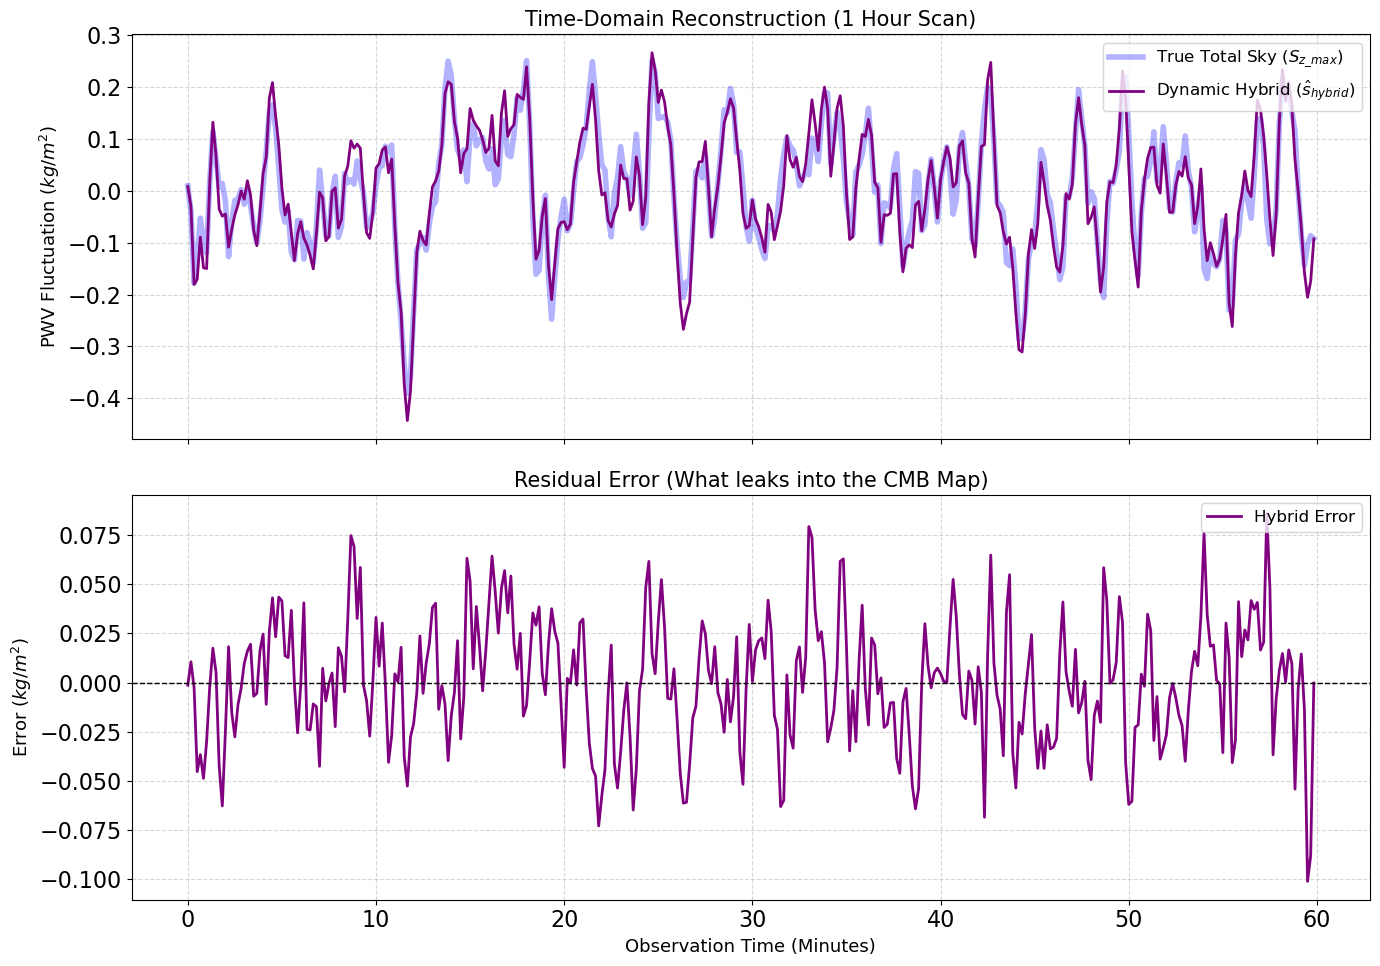

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 11. Constructing the Full-Spectrum Hybrid Estimator
# ==============================================================================
print(f"Building Full-Spectrum Hybrid Estimator and returning to Time Domain...")

dt_lidar = 10.0  # seconds

N_time = s_i.shape[-1] # e.g., 360 time steps

# 1. Generate the FULL frequency axis (Positive, DC, Negative)
freqs_full = np.fft.fftfreq(N_time, d=dt_lidar)

# 2. Enforce Hermitian Symmetry for z_opt
# We map every frequency (positive or negative) to its absolute value
# to find the correct optimal altitude index we calculated earlier.
optimal_z_indices_full = np.zeros(N_time, dtype=int)
for i, f in enumerate(freqs_full):
    # Find the closest positive frequency in our original Welch 'freqs' array
    closest_f_idx = np.argmin(np.abs(freqs - np.abs(f)))
    optimal_z_indices_full[i] = optimal_z_indices[closest_f_idx]

# 3. Vectorized Time-Domain Summation
x_cumsum_time = np.cumsum(x_i[:obs_hours, :, :], axis=1)

# 4. Massive Vectorized FULL FFT (Not rfft)
X_all_z_fft = np.fft.fft(x_cumsum_time, axis=-1)
S_true_fft = np.fft.fft(s_z_max[:obs_hours, :], axis=-1)

# 5. The Stitching Loop
S_hat_hybrid_fft = np.zeros((obs_hours, N_time), dtype=complex)
for f_idx in range(N_time):
    best_z_idx = optimal_z_indices_full[f_idx]
    S_hat_hybrid_fft[:, f_idx] = X_all_z_fft[:, best_z_idx, f_idx]

# ==============================================================================
# 12. The Inverse Fast Fourier Transform (IFFT)
# ==============================================================================
# We use .real to discard floating-point machine noise (e.g., + 1e-16j)
s_hat_hybrid_time = np.fft.ifft(S_hat_hybrid_fft, axis=-1).real

# Extract the static 4000m cutoff for a baseline comparison
static_z_idx = np.argmin(np.abs(altitudes - 4000.0))
x_static_time = x_cumsum_time[:, static_z_idx, :]

# ==============================================================================
# Plotting the Time-Domain Reality Check
# ==============================================================================
sim_idx = 1
time_axis_min = np.arange(N_time) * dt_lidar / 60.0

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ------------------------------------------------------------------------------
# Panel 1: The Reconstructed Signals
# ------------------------------------------------------------------------------
axs[0].plot(time_axis_min, s_z_max[sim_idx, :], color='blue', linewidth=4, alpha=0.3, label=r'True Total Sky ($S_{z\_max}$)')
#axs[0].plot(time_axis_min, x_static_time[sim_idx, :], color='orange', alpha=0.7, label=r'Static Lidar ($X_{4000m}$)')
axs[0].plot(time_axis_min, s_hat_hybrid_time[sim_idx, :], color='purple', linewidth=2, label=r'Dynamic Hybrid ($\hat{s}_{hybrid}$)')

axs[0].set_title('Time-Domain Reconstruction (1 Hour Scan)', fontsize=15)
axs[0].set_ylabel(r'PWV Fluctuation ($kg/m^2$)', fontsize=13)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(loc='upper right', fontsize=12)

# ------------------------------------------------------------------------------
# Panel 2: The Subtraction Residuals (The Error Injected into the Bolometer)
# ------------------------------------------------------------------------------
# Error = Estimator - True Sky
err_static = x_static_time[sim_idx, :] - s_z_max[sim_idx, :]
err_hybrid = s_hat_hybrid_time[sim_idx, :] - s_z_max[sim_idx, :]

#axs[1].plot(time_axis_min, err_static, color='orange', alpha=0.7, label=r'Static Error')
axs[1].plot(time_axis_min, err_hybrid, color='purple', linewidth=2, label=r'Hybrid Error')

axs[1].axhline(0, color='black', linestyle='--', linewidth=1)
axs[1].set_title('Residual Error (What leaks into the CMB Map)', fontsize=15)
axs[1].set_xlabel('Observation Time (Minutes)', fontsize=13)
axs[1].set_ylabel(r'Error ($kg/m^2$)', fontsize=13)
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

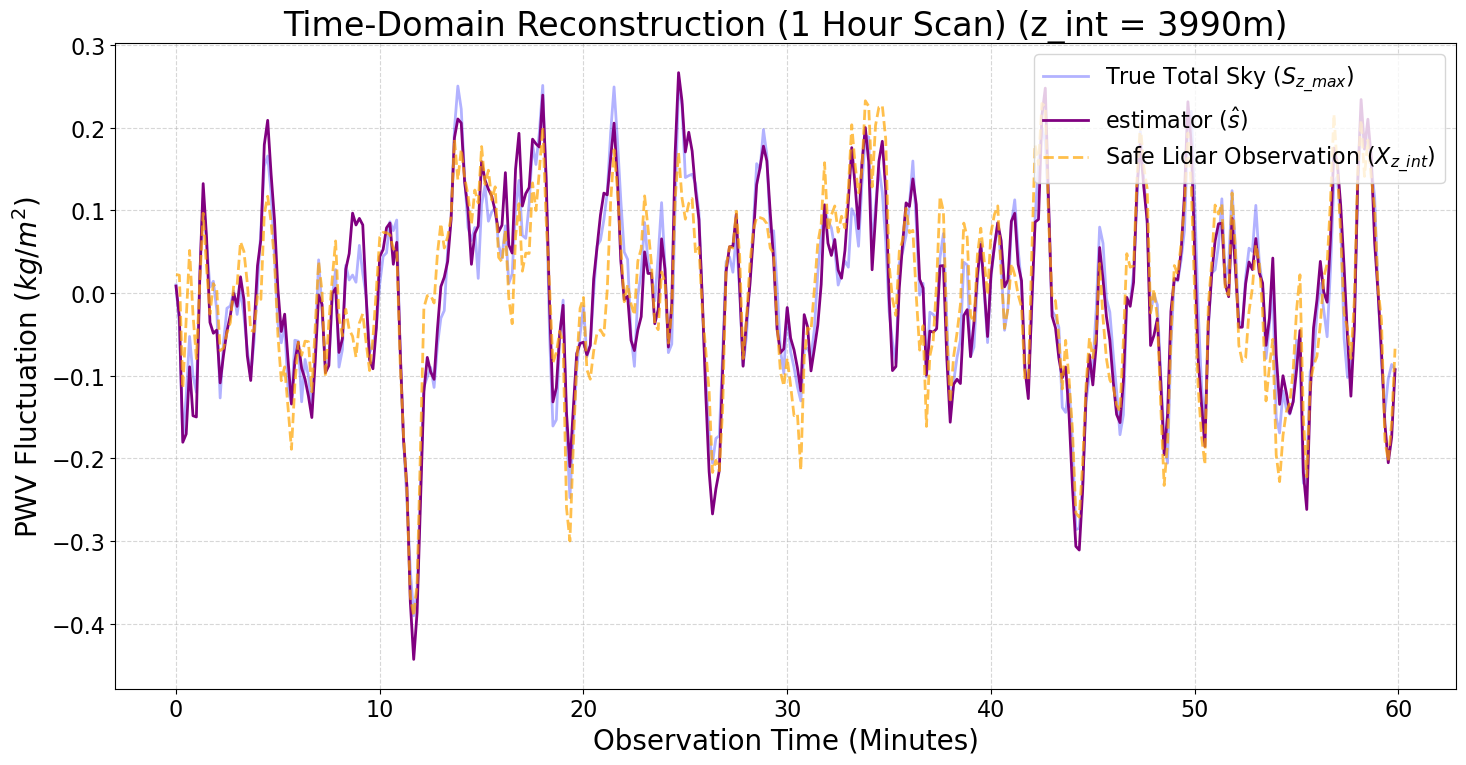

In [34]:
import matplotlib.pyplot as plt

# Single-panel comparison based on the first plot from the hybrid estimator cell.
fig = plt.figure(figsize=(15,8))
plt.plot(time_axis_min, s_z_max[sim_idx, :], color='blue', linewidth=2, alpha=0.3, label=r'True Total Sky ($S_{z\_max}$)')
plt.plot(time_axis_min, s_hat_hybrid_time[sim_idx, :], color='purple', linewidth=2, label=r'estimator ($\hat{s}$)')
plt.plot(time_axis_min, x_z_int[sim_idx, :], color='orange', linewidth=2, linestyle='--', alpha=0.7, label=r'Safe Lidar Observation ($X_{z\_int}$)')

plt.title('Time-Domain Reconstruction (1 Hour Scan) (z_int = 3990m)')
plt.xlabel('Observation Time (Minutes)')
plt.ylabel(r'PWV Fluctuation ($kg/m^2$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [24]:
print(freqs)

[0.         0.00027778 0.00055556 0.00083333 0.00111111 0.00138889
 0.00166667 0.00194444 0.00222222 0.0025     0.00277778 0.00305556
 0.00333333 0.00361111 0.00388889 0.00416667 0.00444444 0.00472222
 0.005      0.00527778 0.00555556 0.00583333 0.00611111 0.00638889
 0.00666667 0.00694444 0.00722222 0.0075     0.00777778 0.00805556
 0.00833333 0.00861111 0.00888889 0.00916667 0.00944444 0.00972222
 0.01       0.01027778 0.01055556 0.01083333 0.01111111 0.01138889
 0.01166667 0.01194444 0.01222222 0.0125     0.01277778 0.01305556
 0.01333333 0.01361111 0.01388889 0.01416667 0.01444444 0.01472222
 0.015      0.01527778 0.01555556 0.01583333 0.01611111 0.01638889
 0.01666667 0.01694444 0.01722222 0.0175     0.01777778 0.01805556
 0.01833333 0.01861111 0.01888889 0.01916667 0.01944444 0.01972222
 0.02       0.02027778 0.02055556 0.02083333 0.02111111 0.02138889
 0.02166667 0.02194444 0.02222222 0.0225     0.02277778 0.02305556
 0.02333333 0.02361111 0.02388889 0.02416667 0.02444444 0.0247

In [35]:
dt_lidar = 10 #s
s_estimator = np.zeros(360)


Building the Hybrid Dynamic Estimator for 99 hours...


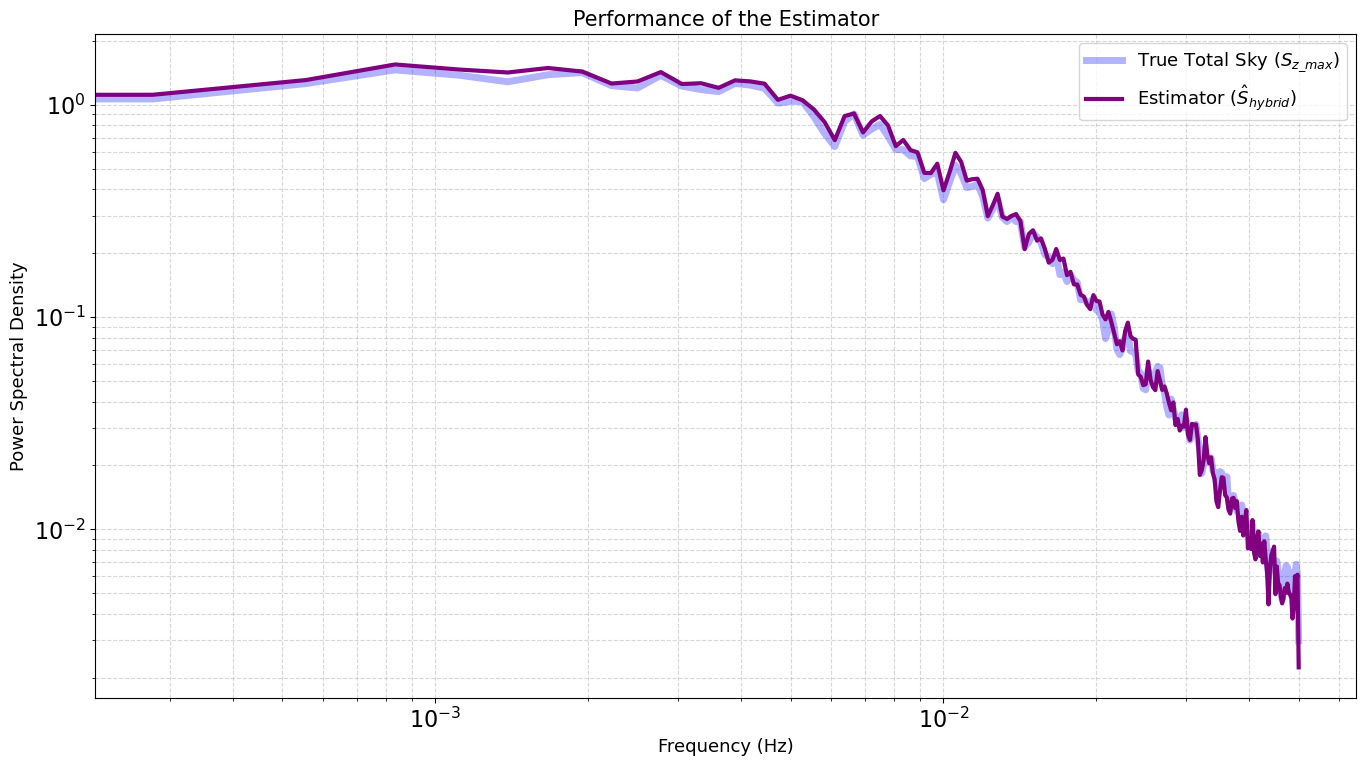

In [36]:
# ==============================================================================
# 11. Constructing the Hybrid Dynamic Estimator PSD
# ==============================================================================
print(f"Building the Hybrid Dynamic Estimator for {obs_hours} hours...")

# 1. Pre-calculate the Auto-Spectrum for every single Lidar integration altitude
master_psd_x = np.zeros((Nz, len(freqs)))

for z_idx in range(1, Nz):
    x_z_current = np.sum(x_i[:obs_hours, :z_idx, :], axis=1)
    _, psd_x = welch(x_z_current, fs=fs_lidar, nperseg=n_window, axis=-1)
    master_psd_x[z_idx, :] = np.mean(psd_x, axis=0)

# 2. Extract the winning z_idx for every frequency (from our previous SNR matrix)
# We calculate it across all frequencies here (including f=0)
optimal_z_indices_all = np.argmax(master_snr_f, axis=0)

# 3. Stitch together the Hybrid Estimator
psd_hybrid_estimator = np.zeros(len(freqs))

for f_idx in range(len(freqs)):
    # Look up the winning altitude index for this specific frequency
    best_z_idx = optimal_z_indices_all[f_idx]
    
    # Grab the power from that specific altitude's spectrum
    psd_hybrid_estimator[f_idx] = master_psd_x[best_z_idx, f_idx]

# ==============================================================================
# Plotting the Hybrid Estimator vs Reality
# ==============================================================================
plt.figure(figsize=(14, 8))

# 1. The Ultimate Target (Total Sky)
plt.loglog(freqs, psd_s_z_max_mean, label=r'True Total Sky ($S_{z\_max}$)', color='blue', linewidth=5, alpha=0.3)

# 2. A Standard Static Cutoff (e.g., locked at 4000m)
static_z_idx = np.argmin(np.abs(altitudes - 4000.0))
#plt.loglog(freqs, master_psd_x[static_z_idx, :], label=r'Static Estimator ($X_{4000m}$)', color='orange', linestyle='--', linewidth=2)

# 3. YOUR HYBRID ESTIMATOR
plt.loglog(freqs, psd_hybrid_estimator, label=r'Estimator ($\hat{S}_{hybrid}$)', color='purple', linewidth=3)

plt.title('Performance of the Estimator', fontsize=15)
plt.xlabel('Frequency (Hz)', fontsize=13)
plt.ylabel('Power Spectral Density', fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right', fontsize=13)
plt.tight_layout()
plt.show()

Building the Error Matrix and stitching the Hybrid Error...


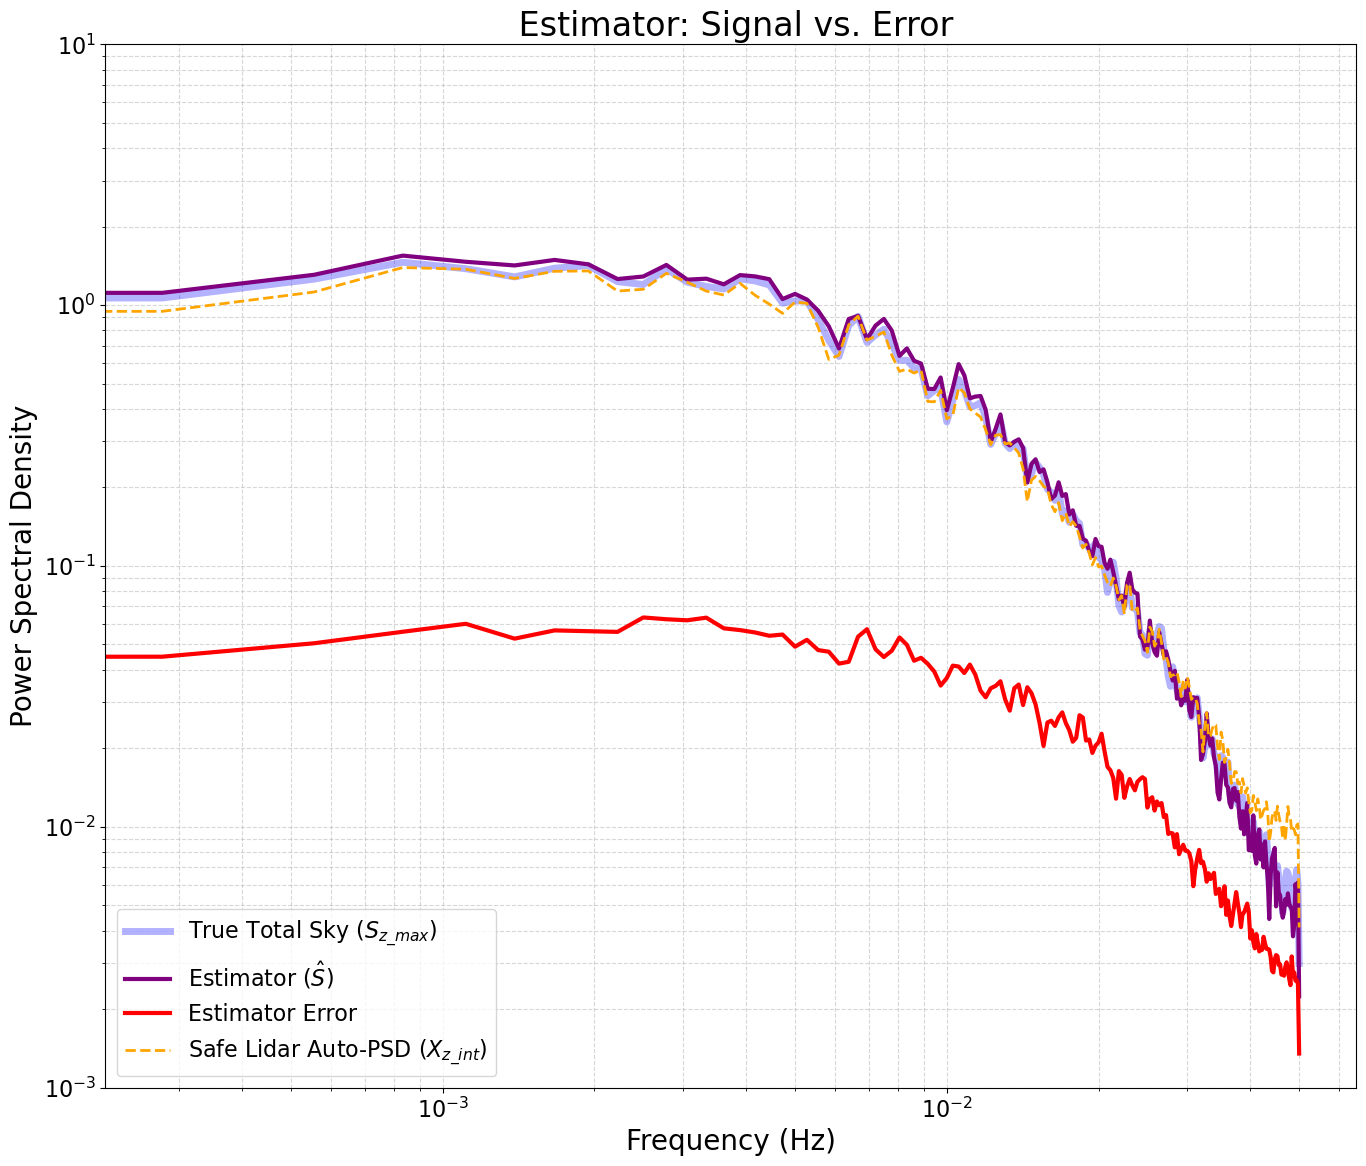

In [40]:
# ==============================================================================
# 4. Constructing the Hybrid Error PSD (Vectorized)
# ==============================================================================
print(f"Building the Error Matrix and stitching the Hybrid Error...")

# Pre-calculate the True Error PSD for every single integration altitude
master_psd_error = np.zeros((Nz, len(freqs)))

for z_idx in range(1, Nz):
    x_z_current = np.sum(x_i[:obs_hours, :z_idx, :], axis=1)
    
    # Calculate the PSD of the complex difference (accounts for amplitude AND phase)
    _, psd_error = welch(x_z_current - s_z_max[:obs_hours, :], fs=fs_lidar, nperseg=n_window, axis=-1)
    master_psd_error[z_idx, :] = np.mean(psd_error, axis=0)

# Fully vectorized stitching for HPC performance
# We use advanced NumPy indexing to extract the winning values instantly without a for-loop
freq_indices = np.arange(len(freqs))

# Stitch the Estimator PSD (replaces your previous for-loop)
psd_hybrid_estimator = master_psd_x[optimal_z_indices_all, freq_indices]

# Stitch the Error PSD
psd_hybrid_error = master_psd_error[optimal_z_indices_all, freq_indices]

# Extract a static cutoff (e.g., locked at 4000m) as a baseline comparison
static_z_idx = np.argmin(np.abs(altitudes - 4000.0))
psd_static_error = master_psd_error[static_z_idx, :]


# ==============================================================================
# Plotting the Hybrid Estimator vs Reality vs Error
# ==============================================================================
plt.figure(figsize=(14, 12))

# 1. The Ultimate Target (Total Sky)
plt.loglog(freqs, psd_s_z_max_mean, label=r'True Total Sky ($S_{z\_max}$)', color='blue', linewidth=5, alpha=0.3)

# 2. YOUR HYBRID ESTIMATOR
plt.loglog(freqs, psd_hybrid_estimator, label=r'Estimator ($\hat{S}$)', color='purple', linewidth=3)

# 3. THE HYBRID ERROR
plt.loglog(freqs, psd_hybrid_error, label=r'Estimator Error', color='red', linewidth=3)

plt.loglog(freqs, psd_x_z_int_mean, label=rf'Safe Lidar Auto-PSD ($X_{{z\_int}}$)', color='orange', linestyle='--', linewidth=2)


plt.title(' Estimator: Signal vs. Error')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')

plt.ylim(1e-3, 1e1)  # Set Y-axis limits to frame the crossing point cleanly

# Moved legend to lower left to keep the high-frequency intersection clear
plt.legend(loc='lower left') 
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
# Pick a single 1-hour simulation to analyze
dt_lidar = 10.0  # seconds
sim_idx = 0 




<>:72: SyntaxWarning: invalid escape sequence '\h'
<>:72: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_333281/2601747841.py:72: SyntaxWarning: invalid escape sequence '\h'
  axs[1].semilogx(freqs_fft, phase_hybrid - phase_true, label='Hybrid Estimator Error ($\hat{S}_{hybrid}$)', color='purple', linewidth=2)


Extracting raw complex Fourier coefficients for Simulation 0...


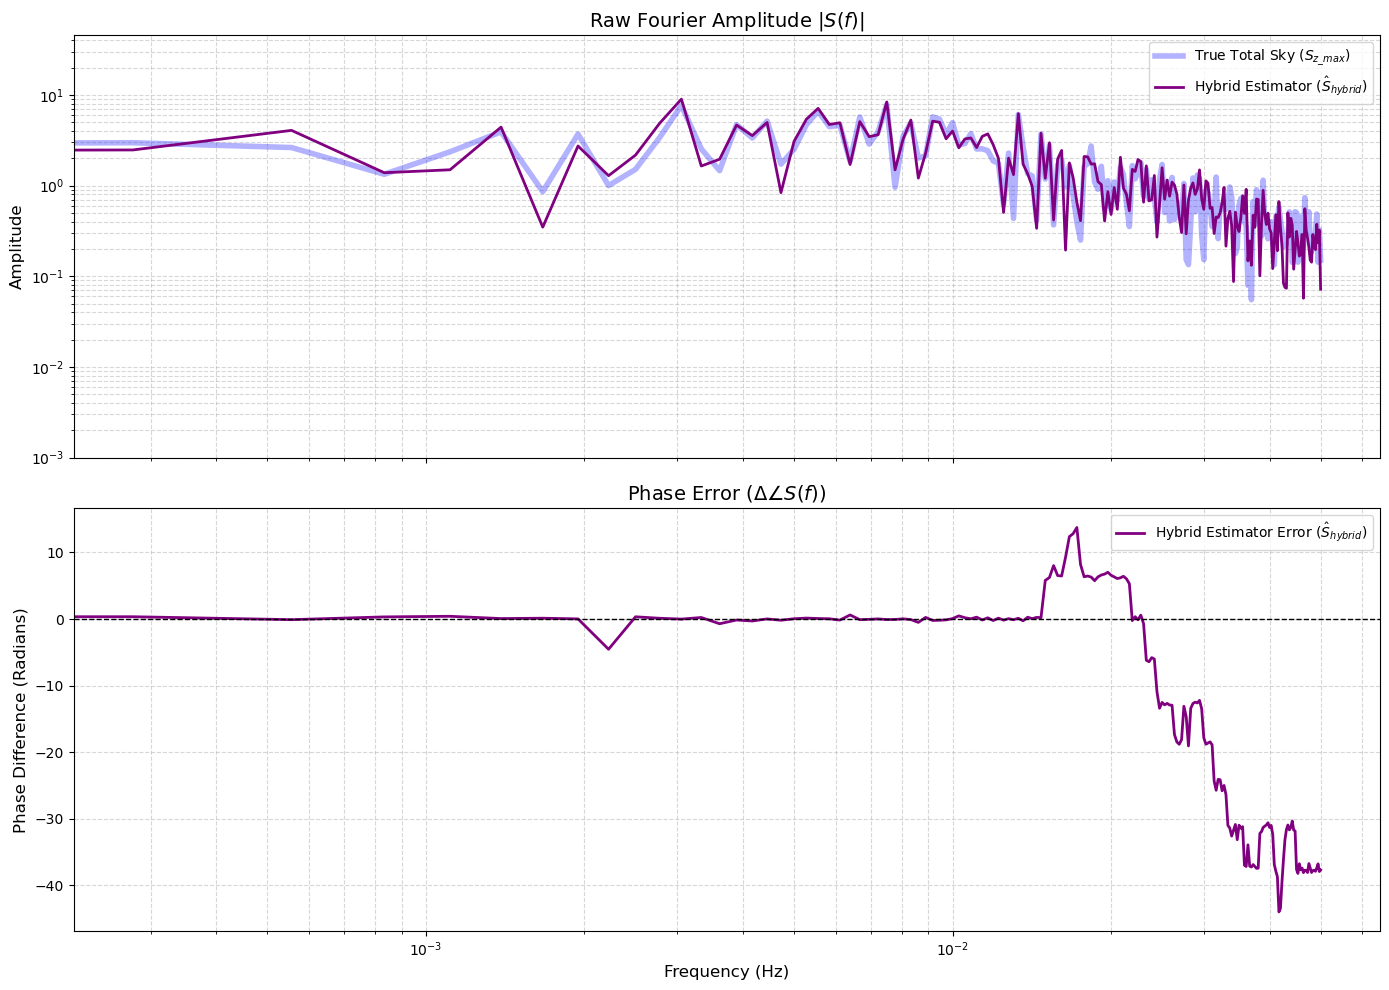

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 12. Constructing the Complex Fourier Estimator
# ==============================================================================
print("Extracting raw complex Fourier coefficients for Simulation 0...")

# Pick a single 1-hour simulation to analyze
dt_lidar = 10.0  # seconds
sim_idx = 0 
s_z_max_1d = s_z_max[sim_idx, :]

# 1. Raw FFT of the True Total Sky
# rfft is for real-valued time inputs; it returns the positive frequencies
S_true_complex = np.fft.rfft(s_z_max_1d)
freqs_fft = np.fft.rfftfreq(len(s_z_max_1d), d=dt_lidar)

# 2. Raw FFT for every single Lidar integration altitude
X_all_z_complex = np.zeros((Nz, len(freqs_fft)), dtype=complex)
for z_idx in range(1, Nz):
    x_z_1d = np.sum(x_i[sim_idx, :z_idx, :], axis=0)
    X_all_z_complex[z_idx, :] = np.fft.rfft(x_z_1d)

# 3. Construct your Dynamic Hybrid Estimator in the complex plane
S_hybrid_complex = np.zeros(len(freqs_fft), dtype=complex)

for f_idx in range(len(freqs_fft)):
    # Get the statistically optimal altitude for this specific frequency bin
    best_z_idx = optimal_z_indices_all[f_idx] 
    
    # Extract the complex coefficient (Amplitude + Phase) from that altitude
    S_hybrid_complex[f_idx] = X_all_z_complex[best_z_idx, f_idx]

# 4. For baseline comparison, get a static cutoff (e.g., 4000m)
static_z_idx = np.argmin(np.abs(altitudes - 4000.0))
X_static_complex = X_all_z_complex[static_z_idx, :]

# ==============================================================================
# Extract Magnitude and Phase
# ==============================================================================
# Magnitude = Absolute value of the complex number
mag_true = np.abs(S_true_complex)
mag_hybrid = np.abs(S_hybrid_complex)

# Phase = Angle of the complex number (unwrapped to prevent artificial jumps from pi to -pi)
phase_true = np.unwrap(np.angle(S_true_complex))
phase_hybrid = np.unwrap(np.angle(S_hybrid_complex))
phase_static = np.unwrap(np.angle(X_static_complex))

# ==============================================================================
# Plotting the Complex Comparison
# ==============================================================================
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ------------------------------------------------------------------------------
# Panel 1: Amplitude (Magnitude)
# ------------------------------------------------------------------------------
axs[0].loglog(freqs_fft, mag_true, label=r'True Total Sky ($S_{z\_max}$)', color='blue', linewidth=4, alpha=0.3)
axs[0].loglog(freqs_fft, mag_hybrid, label=r'Hybrid Estimator ($\hat{S}_{hybrid}$)', color='purple', linewidth=2)
axs[0].set_title('Raw Fourier Amplitude $|S(f)|$', fontsize=14)
axs[0].set_ylabel('Amplitude', fontsize=12)
axs[0].grid(True, which="both", ls="--", alpha=0.5)
axs[0].legend(loc='upper right')
axs[0].set_ylim(bottom=1e-3)  

# ------------------------------------------------------------------------------
# Panel 2: Phase Alignment (The Reality Check)
# ------------------------------------------------------------------------------
# We plot the phase difference from the true sky (closer to 0 is better)
#axs[1].semilogx(freqs_fft, phase_static - phase_true, label='Static Estimator Error ($X_{4000m}$)', color='orange', alpha=0.7)
axs[1].semilogx(freqs_fft, phase_hybrid - phase_true, label='Hybrid Estimator Error ($\hat{S}_{hybrid}$)', color='purple', linewidth=2)

axs[1].axhline(0, color='black', linestyle='--', linewidth=1) # The line of perfect phase
axs[1].set_title(r'Phase Error ($\Delta \angle S(f)$)', fontsize=14)
axs[1].set_xlabel('Frequency (Hz)', fontsize=12)
axs[1].set_ylabel('Phase Difference (Radians)', fontsize=12)
axs[1].grid(True, which="both", ls="--", alpha=0.5)
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()